# **Sección 2. Entrenamiento y evaluación de modelos**

n esta sección se presenta el entrenamiento de los cuatro modelos: ``Random Forest``, ``XGBoost``, ``CatBoost`` y ``LightGBM``, cuyo rendimiento se evaluará mediante curvas ROC, matrices de confusión y métricas de clasificación. Para el ajuste de hiperparámetros se utilizará GridSearchCV con validación cruzada StratifiedKFold de 5 pliegues, garantizando que la proporción entre clases se mantenga en cada partición dado el desbalance presente en el dataset.

## **2.1 Importación de librerías**

Antes de iniciar, cargamos las librerías a utilizar en todo este proceso de modelado, de la optimización de hiperparámetros y el uso de validación cruzada.

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score,  recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import joblib
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
import seaborn as sns


import time
import ctypes

# Cargamos los archivos joblib con los datos preprocesados
X_train = joblib.load("../data/X_train.joblib")
X_test = joblib.load("../data/X_test.joblib")
y_train = joblib.load("../data/y_train.joblib")
y_test = joblib.load("../data/y_test.joblib")
preprocesador = joblib.load("../data/preprocessor.joblib")

# definimos semilla para reproducibilidad
RANDOM_STATE = 42

## **2.2 Validación cruzada**

Por instrucciones del ejercicio se utiliza una partición estratificada de 5 pliegues mediante ``StratifiedKFold``. Esta elección es acertada dado el desbalance evidente en el dataset, ya que al mantener la proporción de clases en cada pliegue se garantizan resultados más representativos y sin ningún tipo de sesgo o filtración de datos entre conjuntos.

In [2]:
# definimos la estrategia de validación cruzada estratificada a usar
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## **2.3 Construcción del Pipeline**

Dado que ya se realizó todo el preprocesamiento previo, se procede con el modelado. Para esto se construye un Pipeline que permite aplicar transformaciones como el escalado y la codificación de variables categóricas de manera ordenada y sin riesgo de fuga de datos entre el conjunto de entrenamiento y prueba, tal como se vio en clase. Para su construcción se aprovecha el preprocesador definido anteriormente.

In [3]:

# dependiendo del modelo que se quiera usar, se puede cambiar el nombre del modelo y el modelo en sí
def construir_pipeline(modelo, nombre_modelo, preprocessor):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])
    return pipeline

Ahora, crearemos varias funciones reutilizables antes de entrenar el modelo para hacer el proceso más eficiente y evitar hacer código demás.

In [4]:
def evaluar_modelo(modelo, nombre, X_test, y_test):
    
    y_pred = modelo.predict(X_test) # lo que predice el modelo
    y_prob = modelo.predict_proba(X_test)[:, 1] # probabilidades
    
    # calculamos todas las métricas
    return {
        "Modelo": nombre,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Test ROC AUC": roc_auc_score(y_test, y_prob),
        
    }  

Esta función se usa para evaluar el modelo bajo distintas métricas. Es útil para comparar que tan bien generaliza nuestro modelo y comparar con las métricas obtenidas en validación cruzada

In [5]:
def entrenar_modelo(model, nombre_modelo, preproccesor, param_grid, X_train, y_train, X_test, y_test, cv, n_jobs):
    
    # guardamos los resultados 
    resultados_totales = {}
    
    
    # construimos el pipeline
    pipeline = construir_pipeline(model, nombre_modelo, preproccesor)
    
    # aplicamos GridSearchCV para encontrar los mejores hiperparámetros
    grid_search = GridSearchCV(
        estimator=pipeline,  # le pasamos el pipeline
        param_grid=param_grid, # espacio de búsqueda
        scoring="roc_auc", # métrica a optimizar
        cv=cv, # validación cruzada
        n_jobs=n_jobs,  # usa todos los cores
        verbose=1
    )
    
    # medimos tiempo
    inicio = time.time()
    grid_search.fit(X_train, y_train)
    tiempo = time.time() - inicio
    
    # hacemos la evaluación para el mejor modelo 
    evaluacion = evaluar_modelo(
            grid_search.best_estimator_,
            f"Grid Search - {nombre_modelo}",
            X_test,
            y_test
        
    )
    
    # guardamos los resultados en una lista
    resultados_totales[nombre_modelo] = {
         **evaluacion,
         "Mejores Hiperparámetros": grid_search.best_params_,
            "Mejor ROC AUC CV": grid_search.best_score_,
         "Tiempo (s)": tiempo,
            "Iteraciones": len(grid_search.cv_results_['params']),
        }
    
    print(f"Tiempo: {tiempo:.2f}s | Mejor ROC AUC CV: {grid_search.best_score_:.4f}")
    print(f"Mejores params: {grid_search.best_params_}")
    
    # retornamos lista con resultados
    return resultados_totales, grid_search.best_estimator_

La anterior función utiliza `GridSearchCV` como método de optimización de hiperparámetros, el cual recibira un espacio de búsqueda predefinido para cada modelo y el pipeline. Posteriormente, se entrena y se evalua con la función ya descrita. Todo estos resultados se guardan en una lista para visualizarlo de la mejor manera.

Por último, definiremos las siguientes funciones para hacer la matriz de confusión y la curva ROC:

In [72]:
def graficar_resultados(y_test, predicciones, probabilidades, nombre_modelo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # matriz de confusión
    matriz = confusion_matrix(y_test, predicciones)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["No Churn (0)", "Churn (1)"]  # cambiado
    )
    cm_display.plot(cmap='Blues', values_format='d', ax=axes[0])
    axes[0].set_title(f"Matriz de Confusión — {nombre_modelo}")

    # curva ROC
    fpr, tpr, _ = roc_curve(y_test, probabilidades)
    auc = roc_auc_score(y_test, probabilidades)
    axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
    axes[1].plot([0, 1], [0, 1], color="orange", linestyle="--", lw=2, label="Clasificador aleatorio")
    axes[1].set_xlabel("Tasa de Falsos Positivos")
    axes[1].set_ylabel("Tasa de Verdaderos Positivos")
    axes[1].set_title(f"Curva ROC — {nombre_modelo}")
    axes[1].grid(True)
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## **2.4 Entrenamiento modelos**

Ahora si, con las funciones definidas y los pipelines construidos, se procederá al entrenamiento de los modelos asignados. Para cada uno se definira un espacio de búsqueda de hiperparámetros, teninendo en cuenta tanto las recomendaciones encontradas en la literatura y la estructura del dataset. La métrica a optimizar será ROC AUC, ya que permite evaluar la capacidad del modelo para diferenciar entre ambas clases y mantener un equilibrio general entre las métricas de clasificación.

En este caso, dado al desbalance que se presenta en el dataset se incorporarán parámetros como `class_weight`, `scale_pos_weight` y `auto_class_weights` en los modelos correspondientes, con el fin de otorgar una mayor importancia a la clase minoritaria. Esto permite que, aunque la optimización se realice sobre `roc_auc`, no se vea excesivamente afectado el desempeño de otras métricas relevante como el `recall`, el cual resulta especialmente importante en este contexto, pues representa la capacidad del modelo para identificar correctamente a los clientes con mayor probabilidad de abandono (churn).

### **2.4.1 Random Forest**

Primero, definiremos el espacio de búsqueda definido para este modelo. Utilizaremos parámetros, aparte de los convencionales como `n_estimators` (número de árboles) o `max_depth` (máxima profundidad permitida), los recomendados en la asignación: `min_samples_split`, tamaño mínimo para dividir nodos/interiores/hoja; `min_samples_leaf`, mínimo de datos necesarios en cada hoja; `max_features`, máximo de features por split; `bootstrap`, método de bootstrapping; y `criterion`, función de criterio (gini/entropy).

In [ ]:
param_grid_rf = {
    'model__n_estimators': [100, 200, 300], 
    'model__max_depth': [10, 20, None],
    "model__min_samples_split":[2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True, False],
    "model__criterion": ["gini", "entropy"]
}

# llamamos al modelo
RandomForest_Model = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')

Se limita n_estimators hasta 300 porque con este tamaño de datos más árboles podría aumentar el costo computacional sin mejoras significativas en el rendimiento. Se incluye max_depth=None para capturar interacciones entre variables fuertes como `Contract` y `tenure`. Valores de min_samples_leaf hasta 4 ayudan a evitar sobreajuste en la clase minoritaria, y se prueban tanto gini como entropy.

In [45]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_rf, mejor_rf = entrenar_modelo(RandomForest_Model, "Random Forest", preprocesador, param_grid_rf, X_train, y_train, X_test, y_test, cv, -1)


# guardamos el modelo
joblib.dump(mejor_rf, "../data/mejor_rf.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Tiempo: 487.40s | Mejor ROC AUC CV: 0.8468
Mejores params: {'model__bootstrap': True, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Modo suspensión restaurado


Observamos que el modelo tardó aproximadamente 8 minutos y 7 segundos en completar el entrenamiento y búsqueda de hiperparámetros, obteniendo un ``ROC AUC`` en validación cruzada de 0.8468. En este caso, el mejor modelo utilizó 200 árboles (``n_estimators = 200``), el criterio de entropía (``entropy``) para la división de nodos, aplicó bootstrap, y estableció una profundidad máxima de 10 (``max_depth = 10``). Además, seleccionó sqrt como número de variables a considerar en cada división, con un mínimo de 4 observaciones por hoja y 2 observaciones para realizar una partición.

### **2.4.1 XGBoost**

De manera análoga, se utilizarán parámetros recomendados en la asignación: `subsample`, proporción de muestras; `colsample_bytree`, proporción de variables por árbol; `gamma`, criterio mínimo para dividir nodos; `min_child_weight`, peso mínimo en nodos hoja; `reg_alpha` y `reg_lambda`, regularización L1/L2; y `scale_pos_weight`, definida en el modelo.

In [53]:
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_lambda': [1, 5],
    'model__reg_alpha': [0, 0.1],
    'model__gamma': [0, 0.1],
    'model__min_child_weight': [1, 3]
}


neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos


# llamamos al modelo
xgb_model = XGBClassifier(
    random_state = RANDOM_STATE,
    scale_pos_weight = scale_pos_weight
)

El espacio de búsqueda para XGBoost considera tanto los hiperparámetros convencionales como los recomendados en la asignación. subsample y colsample_bytree se prueban desde 0.8 para no perder demasiada información dado el tamaño del dataset. gamma se mantiene en valores bajos ya que los datos no presentan ruido excesivo. Para la regularización, reg_alpha parte desde 0 (sin regularización L1) hasta valores moderados, mientras que reg_lambda arranca en 1, que es el default de XGBoost

In [54]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_xgb, mejor_xgb = entrenar_modelo(xgb_model, "XGBoost", preprocesador, param_grid_xgb, X_train, y_train, X_test, y_test, cv, -1)

# guardamos el modelo
joblib.dump(mejor_xgb, "../data/mejor_xgb.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Tiempo: 169.39s | Mejor ROC AUC CV: 0.8500
Mejores params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 100, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 0.8}
Modo suspensión restaurado


Analizando el entrenamiento del modelo, vemos que tardo muchos menos que `Random Forest`, puesto que fueron 6 minutos de diferencia, aparte de eso, obtuvo un ROC AUC en validación cruzada de 0.85. En este caso, el mejor modelo utilizó 100 árboles (n_estimators = 100), una tasa de aprendizaje baja de 0.05 (learning_rate), y una profundidad máxima de 3 (max_depth = 3), sugiriendo un modelo relativamente conservador. Además, empleó un muestreo del 80% de filas y columnas (subsample = 0.8, colsample_bytree = 0.8), sin penalización por gamma, con regularización L1 = 0.1 y L2 = 5, favoreciendo una mejor generalización del modelo.

### **2.4.3 CatBoost**

El modelo CatBoost destaca entre los otros con una particularidad, no es necesario aplicar un preprocesamiento previo a las variables categóricas, dado que internamente este se encarga de hacerlo. Sin embargo, por términos de comparación se realizara de igual manera que los otros para efectos más justos en la comparación. Acá también se integraron los hiperparámetros sugeridos para este modelo.

In [56]:
param_grid_cat = {
    'model__iterations': [100, 200, 300],
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 10],
    'model__subsample': [0.8, 1.0],
    'model__random_strength': [0.5, 1.0]
}

# definimos el modelo y aprovechamos para utilizar la gpu
cat_model = CatBoostClassifier(random_seed = RANDOM_STATE, auto_class_weights='Balanced', verbose=0)

Para CatBoost se exploran los hiperparámetros recomendados. l2_leaf_reg en valores bajos dado que el dataset no es muy ruidoso. subsample se mantiene desde 0.8 para no perder información. Se mantiene una profundidad y una tasa de aprendizaje similar al de los anteriores modelos entrenados.

In [57]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_cat, mejor_cat = entrenar_modelo(cat_model, "CatBoost", preprocesador, param_grid_cat, X_train, y_train, X_test, y_test, cv, -1)

# guardamos el modelo
joblib.dump(mejor_cat, "../data/mejor_cat.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Tiempo: 379.34s | Mejor ROC AUC CV: 0.8506
Mejores params: {'model__depth': 4, 'model__iterations': 200, 'model__l2_leaf_reg': 5, 'model__learning_rate': 0.05, 'model__random_strength': 1.0, 'model__subsample': 0.8}
Modo suspensión restaurado


Observamos que el modelo tardó aproximadamente 6 minutos con 19 segundos en completar el entrenamiento y búsqueda de hiperparámetros, donde obtuvo un `ROC AUC` en validación cruzada de 0.8506, el cual es ligeramente superior al de Random Forest. El mejor modelo utilizó 200 iteraciones, una profundidad de 4 y una taza de aprendizaje de 0.05, no se fue por valores muy extremos. Además, empleó una regularización L2 de 5 y un subsample de 0.8, buscando mejorar la capacidad de generalización.

### **2.4.4 LightGBM**

Por último, probaremos el modelo LightGBM que destaca por su velocidad y eficiencia. También se utilizaron todos los parámetros sugeridos en la asignación.

In [59]:
param_grid_lgbm = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [-1, 10, 20],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 63],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_samples': [20, 50],
    'model__reg_alpha': [0, 0.1],
    'model__reg_lambda': [1, 5]
}

# llamamos al modelo
lgbm_model = LGBMClassifier(
    random_state = RANDOM_STATE,
    class_weight='balanced'
)

Para LightGBM se mantienen rangos similares a los modelos anteriores en n_estimators y max_depth para garantizar consistencia en la comparación. min_child_samples se prueba hasta 50, que con 7K filas ya es bastante restrictivo. subsample y colsample_bytree se mantienen desde 0.8 para no perder información. Para la regularización, reg_alpha parte desde 0 hasta valores moderados y reg_lambda arranca en su default.

In [60]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_lgbm, mejor_lgbm = entrenar_modelo(lgbm_model, "LightGBM", preprocesador, param_grid_lgbm, X_train, y_train, X_test, y_test, cv, -1)

# guardamos el modelo
joblib.dump(mejor_lgbm, "../data/mejor_lgbm.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Tiempo: 653.68s | Mejor ROC AUC CV: 0.8467
Mejores params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__min_child_samples': 20, 'model__n_estimators': 100, 'model__num_leaves': 31, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 0.8}
Modo suspensión restaurado


Se observa que el modelo duro aproximadamente 10 minutos con 53 segundos en completar el entrenamiento, siendo el que más tiempo ha tardado. Alcanzo un `ROC AUC` en validación cruzada de 0.8467, un desempeño similar al obtenido con Random Forest. En este caso, el mejor modelo utilizó 100 árboles, una tasa de aprendizaje de 0.05 y una profundidad máxima de 10. Además, empleó un muestreo del 80% de filas y columnas (subsample = 0.8, colsample_bytree = 0.8), junto con regularización L1 = 0.1 y L2 = 5, buscando reducir el sobreajuste y mejorar la generalización del modelo.

## **2.5 Evaluación por modelo**

Dado que ya tenemos los modelos entrenados, ahora procederemos a evaluar su rendimiento a partir del score de sus métricas, matriz de confusión y curva ROC.

### **2.5.1 Random forest**

In [ ]:
resultados_rf_tabla = pd.DataFrame(resultados_rf).T
display(resultados_rf_tabla.iloc[:, :-1].style.hide(axis="index"))

Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s)
Grid Search - Random Forest,0.770050,0.549020,0.748663,0.633484,0.841796,"{'model__bootstrap': True, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}",0.846786,487.397619


Analizando el desempeño del modelo Random Forest, se observa que obtuvo un ``ROC AUC`` de 0.8467 en validación cruzada y 0.8417 en test, una diferencia aproximadamente de 0.005 puntos. Lo anterior sugiere una buena capacidad de generalización del modelo y apenas un leve indicio de overfitting, el cual parece mantenerse controlado. Ahora, en términos de detectar si un cliente realmente desea abandonar el servicio, el modelo muestra un comportamiento moderado: presenta una precisión relativamente baja (0.5490) pero un recall moderado (0.7486), lo que indica que, de cada 10 clientes que realmente abandonan, el modelo logra identificar aproximadamente 7, mientras que cerca de 3 no son detectados. Por último, se observa un F1-score moderado (0.63), lo que sugiere un equilibrio aceptable entre precisión y recall, aunque todavía existe margen de mejora en la reducción de falsos positivos.

Ahora, procedamos a graficar las curvas ROC y la matriz de confusión para un análisis más profundo:

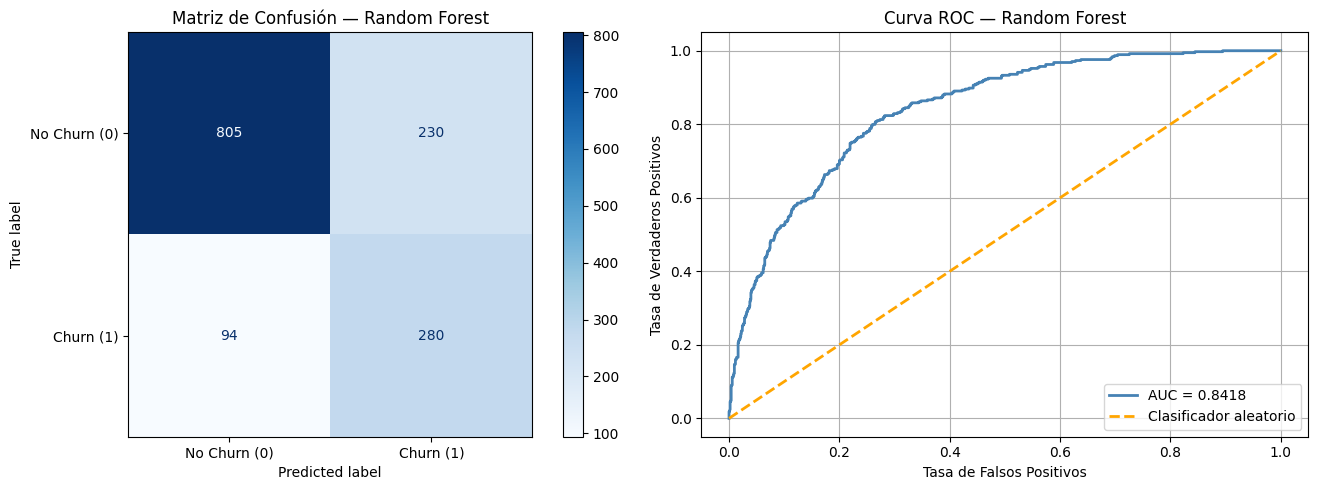

In [62]:
graficar_resultados(
    y_test,
    mejor_rf.predict(X_test),
    mejor_rf.predict_proba(X_test)[:, 1],
    "Random Forest"
)

A partir de la matriz de confusión, se observa que el modelo presentó 94 falsos negativos, es decir, clientes que realmente querían abandonar el servicio pero no fueron detectados por el modelo. Por otro lado, se identifican 230 falsos positivos, correspondientes a clientes que realmente no querían abandonar, pero fueron clasificados como posibles casos de churn. Esto refleja una precisión moderada, ya que una proporción importante de clientes clasificados como abandono realmente no pertenecían a esta categoría. Como se mencionó anteriormente, existe una diferencia entre precision y recall, lo cual puede estar influenciado por el uso de parámetros de balanceo de clases, que suelen favorecer la detección de la clase minoritaria y, por ende, mejorar métricas como el recall, aunque en ocasiones sacrificando precisión.

Al observar la curva ROC, se evidencia un AUC = 0.8418, lo que indica un buen desempeño del modelo para distinguir entre clientes que desean abandonar el servicio y aquellos que no. En términos prácticos, esto sugiere que el modelo tiene aproximadamente un 84% de capacidad discriminativa entre ambas clases. Además, la curva se aproxima relativamente rápido a la esquina superior izquierda, indicando una buena capacidad para identificar clientes con riesgo de abandono manteniendo una tasa moderada de falsos positivos.

### **2.5.2 XGBoost**

In [55]:
# tablamos los resultados
resultados_xgb_tabla = pd.DataFrame(resultados_xgb).T
resultados_xgb_tabla

,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
XGBoost,Grid Search - XGBoost,0.7445,0.511945,0.802139,0.625,0.848224,"{'model__colsample_bytree': 0.8, 'model__gamma...",0.849952,169.388615,1152


Analizando el desempeño del modelo XGBoost, se observa que obtuvo un ROC AUC de 0.8499 en validación cruzada y 0.8482 en test, presentando una diferencia mínima de aproximadamente 0.0017 puntos. Esto sugiere una muy buena capacidad de generalización del modelo, con apenas un leve indicio de overfitting, prácticamente despreciable. En cuanto al desempeño para detectar clientes que desean abandonar el servicio, el modelo presenta una precisión moderada-baja (0.5119), indicando que una proporción importante de clientes clasificados como churn realmente no pertenecen a esta categoría. Sin embargo, el modelo logra un recall alto (0.8021), lo que significa que detecta aproximadamente 8 de cada 10 clientes que realmente desean abandonar el servicio, siendo una característica favorable en este contexto de negocio. Finalmente, se observa un F1-score de 0.6250, considerado moderado, lo que refleja el compromiso existente entre precision y recall, especialmente debido al énfasis del modelo en maximizar la detección de clientes con riesgo de abandono (por scale_pos_weight).

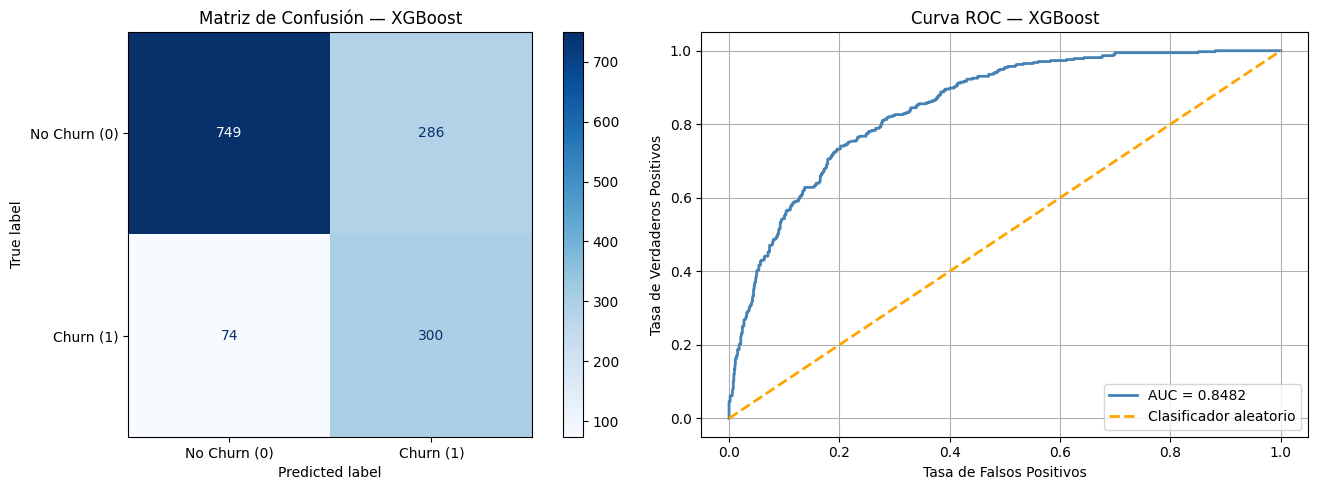

In [63]:
graficar_resultados(
    y_test,
    mejor_xgb.predict(X_test),
    mejor_xgb.predict_proba(X_test)[:, 1],
    "XGBoost"
)

En la matriz de confusión se evidencia que de 1409 clientes en el conjunto de prueba, 749 clientes que no querían abandonar el servicio fueron identificados corretamente, mientras que 300 clientes que realmente deseaban abandonar fueron detectados exitosamente. Asimismo, se observa que 74 clientes con intención de abandono no fueron detectados por el modelo (falsos negativos) y 286 clientes fueron clasificados incorrectamente como posibles casos de abandono, cuando realmente no lo eran (falsos positivos). En este caso, el modelo logra detectar gran parte de los clientes con riesgo de churn, presentando pocos falsos negativos. Aunque existen algunos falsos positivos, en este contexto suelen representar un costo menor para la empresa, ya que una intervención preventiva sobre un cliente que realmente no iba a abandonar el servicio suele ser menos costosa que perder un cliente potencialmente valioso.

De la curva ROC se logra evidenciar un AUC = 0.8482, ligeramente superior al de Random Forest, lo que indica un buen desempeño del modelo para distinguir entre clientes que desean abandonar el servicio y aquellos que no. En términos prácticos, esto sugiere que el modelo tiene aproximadamente un 84% de capacidad discriminativa entre ambas clases, semejante al de Random Forest.

### **2.5.3 CatBoost**

In [58]:
# tablamos los resultados
resultados_cat_tabla = pd.DataFrame(resultados_cat).T
resultados_cat_tabla

,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
CatBoost,Grid Search - CatBoost,0.7445,0.511986,0.799465,0.624217,0.846108,"{'model__depth': 4, 'model__iterations': 200, ...",0.850559,379.338475,288


Es claro que ya se empieza a evidenciar un patrón relativamente estable en los resultados obtenidos, pues no existe una brecha significativa entre el desempeño de los distintos modelos evaluados. En términos generales, la mayoría presenta métricas bastante similares entre sí, lo que sugiere que el dataset podría tener un límite en la capacidad de separación entre clases. En el caso de CatBoost, se obtuvo un ROC AUC de 0.8461, indicando una buena capacidad del modelo para diferenciar entre clientes que desean abandonar el servicio y aquellos que no. Asimismo, presentó un recall alto (0.7994), logrando detectar aproximadamente 8 de cada 10 clientes que realmente desean abandonar, aunque con una precision relativamente baja (0.5120), mostrando nuevamente el compromiso entre ambas métricas. Estos resultados son bastante similares al obtenido con XGBoost.

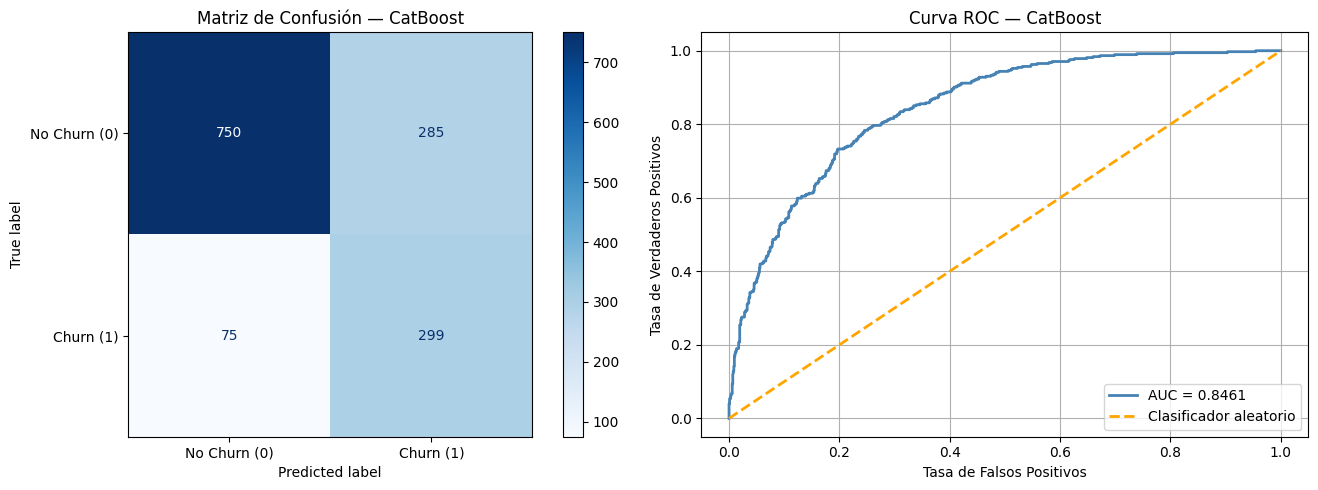

In [71]:
graficar_resultados(
    y_test,
    mejor_cat.predict(X_test),
    mejor_cat.predict_proba(X_test)[:, 1],
    "CatBoost"
)

En base a la matriz de confusión se observa valores similares al modelo de XBoost. Para este modelo, de 1409 clientes se detectaron 750 que no querían abandonar el servicio correctamente, mientras que 299 clientes fueron detectados de manera exitosa. De igual manera, se observa que 75 clientes con intención de abandono no fueron detectados por el modelo (falsos negativos) y 285 clientes fueron clasificados incorrectamente como posibles casos de abandono, cuando realmente no lo eran (falsos positivos), una cantidad considerable. En este caso, el modelo logra detectar gran parte de los clientes con riesgo de churn, presentando pocos falsos negativos, semejante a XGBoost.

Al observar la curva ROC, se evidencia un AUC = 0.8461, indicando una buena capacidad del modelo para discriminar entre clientes que desean abandonar el servicio y aquellos que no. Además, la curva se aproxima relativamente rápido hacia la esquina superior izquierda, sugiriendo una buena capacidad de detección de clientes con churn manteniendo una tasa moderada de falsos positivos.

### **2.5.4 LightGBM**

In [61]:
# tablamos los resultados
resultados_lgbm_tabla = pd.DataFrame(resultados_lgbm).T
resultados_lgbm_tabla

,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
LightGBM,Grid Search - LightGBM,0.757984,0.52973,0.786096,0.632939,0.844818,"{'model__colsample_bytree': 0.8, 'model__learn...",0.846724,653.675391,1152


Analizando el desempeño del modelo LightGBM, se observa que obtuvo un ROC AUC de 0.8467 en validación cruzada y 0.8448 en test, presentando una diferencia mínima de aproximadamente 0.002 puntos, lo que sugiere una buena capacidad de generalización del modelo y poco indicio de sobreajuste. En cuanto a su capacidad para detectar clientes con intención de abandonar el servicio, el modelo presenta un recall alto (0.7861), indicando que logra identificar aproximadamente 8 de cada 10 clientes que realmente desean abandonar. Por otro lado, muestra una precision moderada-baja (0.5297), evidenciando la presencia de falsos positivos. Finalmente, se obtuvo un F1-score de 0.6329, ligeramente superior al de algunos modelos evaluados previamente, reflejando un equilibrio moderado entre precision y recall. Además, el tiempo de entrenamiento fue de aproximadamente 653.68 segundos (10 minutos y 54 segundos), siendo uno de los tiempos computacionales más altos entre los modelos evaluados.

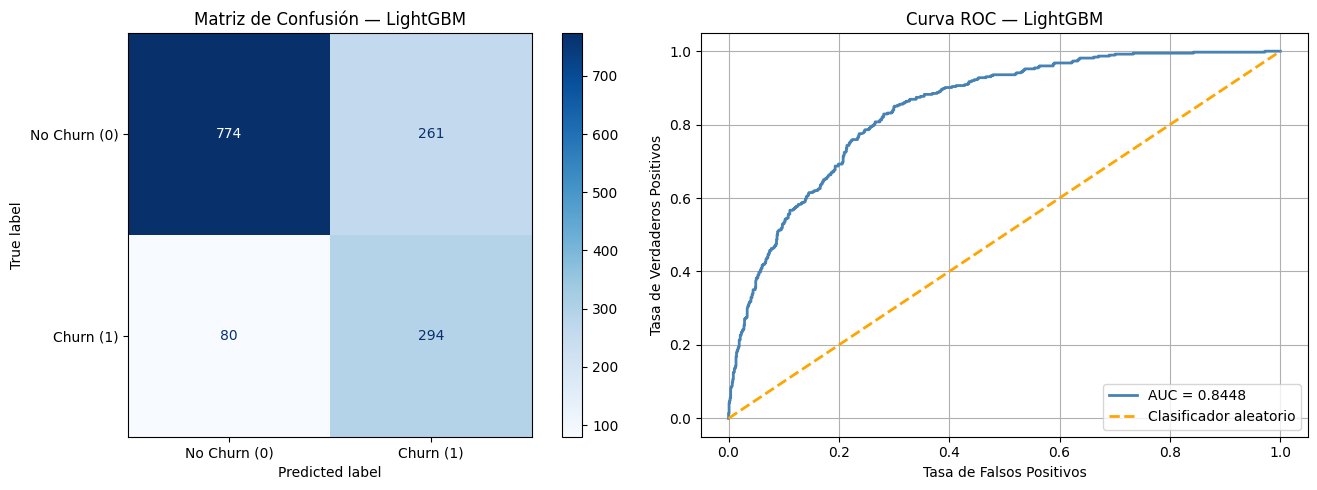

In [73]:
graficar_resultados(
    y_test,
    mejor_lgbm.predict(X_test),
    mejor_lgbm.predict_proba(X_test)[:, 1],
    "LightGBM"
)

A partir de la matriz de confusión, se observa que el modelo identificó correctamente 774 clientes que no deseaban abandonar el servicio y 294 clientes que sí presentaban intención de churn. Asimismo, se evidencian 80 falsos negativos, correspondientes a clientes con intención de abandono que no fueron detectados, y 261 falsos positivos, es decir, clientes clasificados como posibles abandonos cuando realmente no lo eran. Esto confirma nuevamente el patrón observado en modelos anteriores: una alta capacidad para detectar clientes con riesgo de abandono (recall alto), aunque sacrificando algo de precision.

Al observar la curva ROC, se evidencia un AUC = 0.8448, indicando una buena capacidad discriminativa del modelo para diferenciar entre clientes que desean abandonar el servicio y aquellos que no. La curva mantiene un comportamiento similar al de los modelos previamente evaluados, aproximándose relativamente rápido hacia la esquina superior izquierda.

En términos generales, se evidencia un patrón bastante consistente entre todos los modelos evaluados, sin diferencias sustanciales en las métricas obtenidas. Esto sugiere que el dataset podría tener un límite en la capacidad de separación entre clases, haciendo que distintos algoritmos converjan hacia desempeños muy similares, especialmente en métricas como ROC AUC, recall y F1-score.

### **2.5.5 Tabla comparativa general**

Dado que se analizó cada modelo individualmente, se procederá a consolidar los resultados en una tabla comparativa que refleja las métricas de evaluación y el tiempo de entrenamiento de cada uno, con el fin de identificar el modelo con mejor desempeño general.

In [68]:
resultados_finales = pd.concat([
    pd.DataFrame(resultados_rf).T,
    pd.DataFrame(resultados_xgb).T,
    pd.DataFrame(resultados_cat).T,
    pd.DataFrame(resultados_lgbm).T
]).drop(columns=["Modelo"])

resultados_finales

,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
Random Forest,0.77005,0.54902,0.748663,0.633484,0.841796,"{'model__bootstrap': True, 'model__criterion':...",0.846786,487.397619,648
XGBoost,0.7445,0.511945,0.802139,0.625,0.848224,"{'model__colsample_bytree': 0.8, 'model__gamma...",0.849952,169.388615,1152
CatBoost,0.7445,0.511986,0.799465,0.624217,0.846108,"{'model__depth': 4, 'model__iterations': 200, ...",0.850559,379.338475,288
LightGBM,0.757984,0.52973,0.786096,0.632939,0.844818,"{'model__colsample_bytree': 0.8, 'model__learn...",0.846724,653.675391,1152


Tras analizar los resultados de los cuatro modelos, se selecciona CatBoost como modelo final. Su ``ROC AUC CV`` de 0.8506 es el más alto del grupo, siendo esta la métrica más confiable al calcularse sobre 5 particiones distintas y no depender de un split específico. En el conjunto de prueba mantiene un ROC AUC de 0.8461 y un recall de 0.7995, prácticamente idéntico al de XGBoost (0.8021), una diferencia de apenas 0.003 que en términos prácticos es insignificante. Por estas razones, CatBoost ofrece la mejor capacidad discriminatoria general y es el modelo seleccionado para su posterior despliegue.

Por último, pasaremos el archivo a formato .joblib para seguir con la siguiente sección del miniproyecto.

In [78]:
joblib.dump(mejor_cat, "../app/model.joblib")

['../app/model.joblib']